In [2]:
# MODEL: Progressiv boligskat med quasilineære præferencer

# --- Økonomiske variable ---
U_a         = "Nyttefunktion for aldersgruppe a"
c           = "Øvrigt forbrug (kr./år)"
h           = "Boligareal pr. person (m²)"
y           = "Disponibel indkomst (kr./år)"
p           = "Effektiv pris pr. m² (kr./m²/år)"
T_h         = "Samlet skat på bolig, afhænger af areal (kr./år)"
tau_h       = "Marginal skat pr. m² (kr./m²/år)"

# --- Parametre ---
hbar_a      = "Nødvendigt minimumsareal for aldersgruppe a (m²/person)"
beta_a      = "Boligpræferenceparameter for aldersgruppe a - nytte giver en ekstra m² bolig? Høj --> bolig meget værdi" 
h1          = "Grænse for lav skattesats (m²/person)"
h2          = "Grænse for høj skattesats (m²/person)"
tau1        = "Lav skattesats (kr./m²/år)"
tau2        = "Høj skattesats (kr./m²/år)"

# --- Centrale ligninger ---
# Nyttefunktion:
#     U_a(c, h) = c + beta_a * ln(h - hbar_a) 
#
# Budgetrestriktion:
#     c = y - p*h - T(h)
#
# Skattefunktion (stykkevis):
#     T(h) =
#         0,                             if h <= h1
#         tau1 * (h - h1),               if h1 < h <= h2
#         tau1*(h2 - h1) + tau2*(h - h2) if h > h2
#
# Førsteordensbetingelse (inden for ét interval):
#     beta_a / (h - hbar_a) = p + tau(h)
#
# Optimal boligforbrug:
#     h* = hbar_a + beta_a / (p + tau(h))
# ==================================================

In [3]:
import numpy as np
import pandas as pd

# Model for Boligejere
# DATA (m² pr. person, årlige kr.)

rows = [
    ("18-29","Bund 33",   39.0, 59019, 2301750, 148215, 134200),
    ("18-29","Mellem 33", 41.0, 59019, 2419788, 155816, 274600),
    ("18-29","Top 33",    45.0, 59019, 2655865, 171018, 464400),
    ("30-59","Bund 33",   34.7, 59019, 2047967, 131874, 332000),
    ("30-59","Mellem 33", 37.0, 59019, 2183711, 140614, 489500),
    ("30-59","Top 33",    47.3, 59019, 2791609, 179758, 712500),
    ("60+","Bund 33",     61.0, 59019, 3600172, 231824, 288700),
    ("60+","Mellem 33",   64.5, 59019, 3806740, 245125, 467700),
    ("60+","Top 33",      71.5, 59019, 4219874, 271728, 758900),
]
df = pd.DataFrame(rows, columns=["Age","IncomeGroup","h_obs","KvmPrice","PropPrice","cost_y1","Y"])
df["p_eff"] = df["cost_y1"] / df["h_obs"]      # kr pr. m² pr. person pr. år
df["C_obs"] = df["Y"] - df["cost_y1"]

# cost_y1 er de årlige boligomkostninger ved observeret boligstørrelse
# -----------------------------
# SKAT (progressiv pr. person)
# -----------------------------
h1, h2   = 34.0, 55.0          # m²/person (lavere grænser)
tau1, tau2 = 2000.0, 8000.0    # kr/m²/år (større satser for synlig effekt)

def T_total(h):
    """ Samlet skat på boligareal (stykkevis progressiv) """
    if h <= h1:
        return 0.0
    if h <= h2:
        return tau1*(h - h1)
    return tau1*(h2 - h1) + tau2*(h - h2)

# -----------------------------
# PARAMETRE: nødvendigt areal og præferencer (kalibreret)
# -----------------------------
H_BAR = {
    "18-29": 25.0,   # unge
    "30-59": 22.0,   # børnefamilier
    "60+":   30.0    # ældre
}
# Beta beregnes ude fra kr./kvm før skat 
def fit_beta_no_intercept(sub, hbar):
    """ Estimér β som hældning af (h - hbar) ~ 1/p """
    x = 1.0 / sub["p_eff"].to_numpy()
    y = (sub["h_obs"] - hbar).to_numpy()
    beta = float(np.dot(x, y) / np.dot(x, x))
    return max(beta, 1e-6)

age_params = {}
for age, sub in df.groupby("Age"):
    hbar = H_BAR[age]
    beta = fit_beta_no_intercept(sub, hbar)
    age_params[age] = {"hbar": hbar, "beta": beta}

# -----------------------------
# MODEL: quasilinear præferencer med progressiv skat
# -----------------------------
def solve_quasilinear(y, p, hbar, beta):
    """
    Maksimerer U = c + beta*ln(h - hbar) under c = y - p*h - T(h).
    Vurderer kun gyldige valg under SKAT (ikke en 'no_tax'-utility).
    """
    cand = []
    tol = 1e-6

    def add_candidate(tag, h):
        c = y - p*h - T_total(h)
        if (h > hbar + tol) and (c > tol):
            U = c + beta*np.log(h - hbar)
            cand.append((tag, h, c, U, T_total(h)))

# beregner C, U og T(h) for et givet h, og gemmer punktet som muligt “valg”.
            
    # 1) Kandidater fra FOC i hvert stykke (lokal marginalpris)
    for (tau, lo, hi) in [(0.0, -np.inf, h1), (tau1, h1, h2), (tau2, h2, np.inf)]:
        h_k = hbar + beta/(p + tau)
        if (h_k >= lo - 1e-3) and (h_k < hi + 1e-3):
            add_candidate(f"FOC τ={tau:.0f}", h_k)

# Her evalueres det optimale h^* i hvert skatteinterval baseret på den lokale marginalskat 

    # 2) Grænsepunkter (kinks) 
    add_candidate(f"h={h1:.0f}", h1)
    add_candidate(f"h={h2:.0f}", h2)

    # 3) 'No-tax-FOC' som valg MED skat (man kan jo vælge det h men betale skat)
    h_nt = hbar + beta/p
    add_candidate("FOC τ=0 (med skat betalt)", h_nt)

    # Hvis intet gyldigt punkt (meget lav indkomst), vælg minimum over hbar
    if not cand:
        h_eps = hbar + 1e-3
        add_candidate("min over hbar", h_eps)

    # Vælg bedste
    tag, h_star, c_star, U_star, T_star = max(cand, key=lambda t: t[3])
    return {"tag": tag, "h": h_star, "c": c_star, "U": U_star, "T": T_star}


# -----------------------------
# SIMULATION
# -----------------------------
rows_out = []
for _, r in df.iterrows():
    pars = age_params[r["Age"]]
    hbar, beta = pars["hbar"], pars["beta"]
    p = r["p_eff"]
    y = r["Y"]

    # uden skat
    h_nt = hbar + beta / p
    c_nt = y - p*h_nt

    # med skat
    sol = solve_quasilinear(y, p, hbar, beta)

    rows_out.append({
        "Age": r["Age"],
        "IncomeGroup": r["IncomeGroup"],
        "hbar(age)": round(hbar,1),
        "beta(age)": round(beta,1),
        "h_obs": r["h_obs"],
        "h_pred_no_tax": h_nt,
        "h_pred_with_tax": sol["h"],
        "Δh (m²)": sol["h"] - h_nt,
        "Tax_paid (DKK)": sol["T"],
        "tag": sol["tag"]
    })

res = pd.DataFrame(rows_out).sort_values(["Age","IncomeGroup"]).reset_index(drop=True)

# -----------------------------
# OUTPUT
# -----------------------------
print("Aldersparametre (robust kalibrering):")
for a, v in age_params.items():
    print(f"  {a}: hbar={v['hbar']:.1f}, beta={v['beta']:.1f}")

print("\nResultater (før/efter skat):")
print(res.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

Aldersparametre (robust kalibrering):
  18-29: hbar=25.0, beta=63339.8
  30-59: hbar=22.0, beta=67140.2
  60+: hbar=30.0, beta=135547.3

Resultater (før/efter skat):
  Age IncomeGroup  hbar(age)  beta(age)  h_obs  h_pred_no_tax  h_pred_with_tax  Δh (m²)  Tax_paid (DKK)        tag
18-29     Bund 33      25.00  63,339.80  39.00          41.67            34.00    -7.67            0.00       h=34
18-29   Mellem 33      25.00  63,339.80  41.00          41.67            35.92    -5.75        3,839.86 FOC τ=2000
18-29      Top 33      25.00  63,339.80  45.00          41.67            35.92    -5.75        3,839.82 FOC τ=2000
30-59     Bund 33      22.00  67,140.20  34.70          39.67            34.00    -5.67            0.00       h=34
30-59   Mellem 33      22.00  67,140.20  37.00          39.67            34.00    -5.67            0.00       h=34
30-59      Top 33      22.00  67,140.20  47.30          39.67            34.00    -5.67            0.00       h=34
  60+     Bund 33      30.00 

giver det mening med fosrkel i hbar for familier (30-59?) eller bare holde konstant for alle?
Beta siger noget om marginalnytten ved 1 ekstra kvm
h_pred-no_tax = optimerede boligstørrelse (i m² pr. person) uden skat --> “teoretisk optimum” givet ud fra gruppens præferencer og kvadratmeterpris

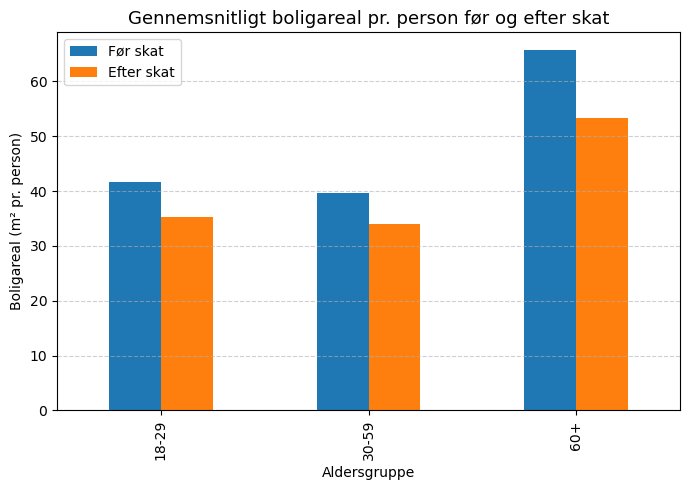

In [4]:
# -----------------------------
# FIGUR A: h* før/efter skat pr. aldersgruppe
# -----------------------------
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,5))

grouped = res.groupby("Age")[["h_pred_no_tax","h_pred_with_tax"]].mean()
grouped.plot(kind="bar", ax=ax, color=["#1f77b4","#ff7f0e"])

ax.set_title("Gennemsnitligt boligareal pr. person før og efter skat", fontsize=13)
ax.set_ylabel("Boligareal (m² pr. person)")
ax.set_xlabel("Aldersgruppe")
ax.legend(["Før skat","Efter skat"])
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

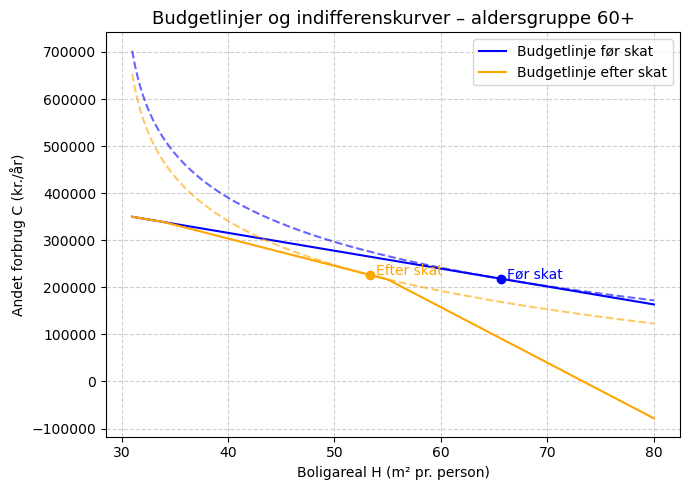

In [5]:
# -----------------------------
# FIGUR B: Budgetlinje og indifferenskurver for 60+ (mellemindkomst)
# -----------------------------
# Vælg en repræsentativ række
sel = df[(df["Age"]=="60+") & (df["IncomeGroup"]=="Mellem 33")].iloc[0]
pars = age_params["60+"]
hbar, beta = pars["hbar"], pars["beta"]
p, y = sel["p_eff"], sel["Y"]

# Nyttemaksimering før og efter skat
h_no_tax = hbar + beta/p
c_no_tax = y - p*h_no_tax
h_with_tax = res.query('Age=="60+" and IncomeGroup=="Mellem 33"')["h_pred_with_tax"].iloc[0]
c_with_tax = y - p*h_with_tax - T_total(h_with_tax)

# Definer budgetlinjer
h_vals = np.linspace(hbar+1, 80, 200)
c_no_tax_line = y - p*h_vals
c_with_tax_line = [y - p*h - T_total(h) for h in h_vals]

# Indifferenskurver (iso-nytte)
U_no_tax = c_no_tax + beta*np.log(h_no_tax - hbar)
U_with_tax = c_with_tax + beta*np.log(h_with_tax - hbar)
def indiff(U): 
    return [U - beta*np.log(h - hbar) for h in h_vals]

# Plot
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(h_vals, c_no_tax_line, label="Budgetlinje før skat", color="blue")
ax.plot(h_vals, c_with_tax_line, label="Budgetlinje efter skat", color="orange")

# Indifferenskurver
ax.plot(h_vals, indiff(U_no_tax), "--", color="blue", alpha=0.6)
ax.plot(h_vals, indiff(U_with_tax), "--", color="orange", alpha=0.6)

# Markér optimale punkter
ax.scatter(h_no_tax, c_no_tax, color="blue")
ax.scatter(h_with_tax, c_with_tax, color="orange")
ax.text(h_no_tax+0.5, c_no_tax, "Før skat", color="blue")
ax.text(h_with_tax+0.5, c_with_tax, "Efter skat", color="orange")

ax.set_title("Budgetlinjer og indifferenskurver – aldersgruppe 60+", fontsize=13)
ax.set_xlabel("Boligareal H (m² pr. person)")
ax.set_ylabel("Andet forbrug C (kr./år)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Substitutionseffekt: Skatten øger relative pris på boligareal --> husholdninger substituerer væk fra bolig mod andet forbrug --> mindre H

Indkomsteffekt: Skatten reducerer den disponible realindkomst --> man bliver generelt fattigere og må reducere både bolig og forbrug. 

Bolig er et normalt nødvendighedsgode. Derfor trækker begge effekter i samme retning (mod lavere boligforbrug)

I denne graf for 60+ ses substitutionseffekten der driver. Valget af H afhænger kun af prisen på H (p + t). C falder kun, fordi budgettet bliver mindre (mekanisk).

indifferenskurven forskydes ned (lavere C,H) → tab af realindkomst (samlet budget skrumper) men dette skal ikke forveksles med en indkomsteffekt. 


Derfor reagerer husholdningen næsten kun gennem substitutionseffekten:
Den vælger et mindre areal (lavere h) for at undgå den højere skat, men det meste af indkomsttabet går på boligdelen

OVERVEJELSER OG TILFØJELSER: 
Vi skal huske at i denne model påvirker indkomst ikke direkte boligvalget. (h* afhænger ikke af Y), hvilket kan undervurdere ulighed. 
Vi kunne lade beta_{a,i}=\beta_a\,(Y_i/\bar Y_a)^\gamma med lille \gamma\in[0.2,0.5] for at få lidt indkomstelasticitet uden at gøre skatten indkomstafhængig.

“Flydende m²” = 0  flytteomkostning
	•	Gør tilpasningen for let ift. den rigtige verden
	•	Fix: tilføj en simpel justeringsomkostning \kappa\cdot|h-h_{-1}| eller en friktionssandsynlighed. Det dæmper kortsigtet effekt og giver jer en dynamisk version (første år vs. langsigt).
	Hvis flytteomkostningen er lavere end skattebetalingen vil folk på lang sigt sikkert flytte

- Provenu-tilbageførsel S med to varianter (fladt vs. målrettet) + indikator for ulighed i boligforbrug.
- evt. 	Let indkomstelasticitet via \beta(Y) (valgfrit).

Anden risiko / shortcomings: 
- Skat pr. person kan give incitament til at “splitte” husstande eller ændre folkeregisteradresse.
Fix: læg en kontrol-omkostning/risiko ind, eller lav scenarie med registrerings-compliance (fx 95 %).
- qvalitet/beliggenhed (q) - 60 m² i City ≠ 60 m² i ydre by.
- Pensionister med stor bolig, men lav indkomst kan rammes hårdt.

In [6]:
# Power-nytte model (opdateret kalibrering af β efter observeret gennemsnitlig boligforbrug normaliseret)
# Målet: realistisk reaktion på kvm-skat, baseret på observeret forbrug pr. aldersgruppe
## β og h̄ (nødvendigt minimumsareal) spiller sammen
# selvom β er højere, kan marginalnytten godt være lavere, hvis (h – h̄) er lille eller hvis husholdningen ligger tættere på sit minimumsbehov
# dermed anden fortolkning af β i power-modellen sammenlignet med log-modellen
# Selvom 30–59 har lidt højere β, så har de lavere optimal h pga. lavere h̄ og deres nyttefunktion (h - h̄)^σ, som mætter hurtigere.
#60+ har derimod både høj β og et stort h - h̄, så marginalnytten forbliver høj længere — de “bliver i store boliger” og betaler skat.

import numpy as np
import pandas as pd

# -----------------------------
# DATA (m² pr. person, årlige kr.)
# -----------------------------
rows = [
    ("18-29","Bund 33",   39.0, 59019, 2301750, 148215, 134200),
    ("18-29","Mellem 33", 41.0, 59019, 2419788, 155816, 274600),
    ("18-29","Top 33",    45.0, 59019, 2655865, 171018, 464400),
    ("30-59","Bund 33",   34.7, 59019, 2047967, 131874, 332000),
    ("30-59","Mellem 33", 37.0, 59019, 2183711, 140614, 489500),
    ("30-59","Top 33",    47.3, 59019, 2791609, 179758, 712500),
    ("60+","Bund 33",     61.0, 59019, 3600172, 231824, 288700),
    ("60+","Mellem 33",   64.5, 59019, 3806740, 245125, 467700),
    ("60+","Top 33",      71.5, 59019, 4219874, 271728, 758900),
]
df = pd.DataFrame(rows, columns=["Age","IncomeGroup","h_obs","KvmPrice","PropPrice","cost_y1","Y"])
df["p_eff"] = df["cost_y1"] / df["h_obs"]    # årlig kr. pr. m² pr. person
df["C_obs"] = df["Y"] - df["cost_y1"]

# -----------------------------
# SKAT (progressiv pr. person)
# -----------------------------
h1, h2   = 34.0, 55.0
tau1, tau2 = 2000.0, 8000.0

def T_total(h):
    if h <= h1:
        return 0.0
    if h <= h2:
        return tau1*(h - h1)
    return tau1*(h2 - h1) + tau2*(h - h2)

# -----------------------------
# PARAMETRE: subsistens og power-nytte
# -----------------------------
H_BAR = {"18-29": 25.0, "30-59": 25.75, "60+": 41.0} # nødvendigt areal pr. aldersgruppe (25 kvm * Beta vægt)
SIGMA = 0.4   # fælles elasticitetsparameter (0 < σ < 1)

# --- Ny kalibrering: β proportional med observeret gennemsnitligt boligareal ---
mean_h = {"18-29": 39.4, "30-59": 40.6, "60+": 64.5}
base_h = mean_h["18-29"]
beta_scale = {age: mean_h[age] / base_h for age in mean_h}  # forhold mellem grupper
beta_base_level = 60000  # skala så resultaterne får realistisk variation

age_params = {}
for age in mean_h:
    hbar = H_BAR[age]
    beta = beta_scale[age] * beta_base_level
    age_params[age] = {"hbar": hbar, "beta": beta}

# -----------------------------
# MODEL: power-quasilinear præferencer
# -----------------------------
def solve_power(y, p, hbar, beta, sigma):
    """Maksimerer U = c + beta*(h-hbar)^sigma under progressiv skat."""
    cand = []
    tol = 1e-6

    def add_candidate(tag, h):
        c = y - p*h - T_total(h)
        if (h > hbar + tol) and (c > tol):
            U = c + beta * (h - hbar)**sigma
            cand.append((tag, h, c, U, T_total(h)))

    # Kandidater fra FOC i hvert skatteinterval
    for (tau, lo, hi) in [(0.0, -np.inf, h1), (tau1, h1, h2), (tau2, h2, np.inf)]:
        h_k = hbar + (beta * sigma / (p + tau))**(1/(1 - sigma))
        if (h_k >= lo - 1e-3) and (h_k < hi + 1e-3):
            add_candidate(f"FOC τ={tau:.0f}", h_k)

    # Grænsepunkter (kinks)
    add_candidate(f"h={h1:.0f}", h1)
    add_candidate(f"h={h2:.0f}", h2)

    # No-tax FOC som check
    h_nt = hbar + (beta * sigma / p)**(1/(1 - sigma))
    add_candidate("FOC τ=0 (med skat betalt)", h_nt)

    if not cand:
        h_eps = hbar + 1e-3
        add_candidate("min over hbar", h_eps)

    tag, h_star, c_star, U_star, T_star = max(cand, key=lambda t: t[3])
    return {"tag": tag, "h": h_star, "c": c_star, "U": U_star, "T": T_star}

# -----------------------------
# SIMULATION
# -----------------------------
rows_out = []
for _, r in df.iterrows():
    pars = age_params[r["Age"]]
    hbar, beta = pars["hbar"], pars["beta"]
    p = r["p_eff"]
    y = r["Y"]

    # uden skat
    h_nt = hbar + (beta * SIGMA / p)**(1/(1 - SIGMA))
    c_nt = y - p*h_nt

    # med skat
    sol = solve_power(y, p, hbar, beta, SIGMA)

    rows_out.append({
        "Age": r["Age"],
        "IncomeGroup": r["IncomeGroup"],
        "hbar(age)": round(hbar,1),
        "beta(age)": round(beta,1),
        "h_obs": r["h_obs"],
        "h_pred_no_tax": h_nt,
        "h_pred_with_tax": sol["h"], # ønskede boligforbrug i fravær af skatter og restriktioner
        "Δh (m²)": sol["h"] - h_nt,
        "Tax_paid (DKK)": sol["T"],
        "tag": sol["tag"]
    })

res = pd.DataFrame(rows_out).sort_values(["Age","IncomeGroup"]).reset_index(drop=True)

# -----------------------------
# OUTPUT
# -----------------------------
print(f"Fælles sigma = {SIGMA}")
print("\nAldersparametre (β skaleret efter observeret boligforbrug):")
for a, v in age_params.items():
    print(f"  {a}: h̄={v['hbar']:.1f}, β={v['beta']:.2f}")

print("\nResultater (før/efter skat):")
print(res.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

Fælles sigma = 0.4

Aldersparametre (β skaleret efter observeret boligforbrug):
  18-29: h̄=25.0, β=60000.00
  30-59: h̄=25.8, β=61827.41
  60+: h̄=41.0, β=98223.35

Resultater (før/efter skat):
  Age IncomeGroup  hbar(age)  beta(age)  h_obs  h_pred_no_tax  h_pred_with_tax  Δh (m²)  Tax_paid (DKK)        tag
18-29     Bund 33      25.00  60,000.00  39.00          46.58            34.00   -12.58            0.00       h=34
18-29   Mellem 33      25.00  60,000.00  41.00          46.58            35.66   -10.91        3,328.16 FOC τ=2000
18-29      Top 33      25.00  60,000.00  45.00          46.58            35.66   -10.91        3,328.10 FOC τ=2000
30-59     Bund 33      25.80  61,827.40  34.70          48.43            36.96   -11.47        5,921.68 FOC τ=2000
30-59   Mellem 33      25.80  61,827.40  37.00          48.43            36.96   -11.47        5,921.84 FOC τ=2000
30-59      Top 33      25.80  61,827.40  47.30          48.43            36.96   -11.47        5,921.82 FOC τ=2000


In [7]:
#Power model
# β og h̄ (nødvendigt minimumsareal) spiller sammen
# selvom β er højere, kan marginalnytten godt være lavere, hvis (h – h̄) er lille 
#eller hvis husholdningen ligger tættere på sit minimumsbehov
# dermed anden fortolkning af β i power-modellen sammenlignet med log-modellen
# Selvom 30–59 har lidt højere β, så har de lavere optimal h pga. lavere h̄ 
#bog deres nyttefunktion (h - h̄)^σ, som mætter hurtigere.
# 60+ har derimod både høj β og et stort h - h̄, så marginalnytten forbliver høj længere
# de “bliver i store boliger” og betaler skat.

import numpy as np
import pandas as pd

# -----------------------------
# DATA (m² pr. person, årlige kr.)
# -----------------------------
rows = [
    ("18-29","Bund 33",   39.0, 59019, 2301750, 148215, 190000), # ændret fra 134200 til 190000 grundet cost_y1> Y
    ("18-29","Mellem 33", 41.0, 59019, 2419788, 155816, 274600),
    ("18-29","Top 33",    45.0, 59019, 2655865, 171018, 464400),
    ("30-59","Bund 33",   34.7, 59019, 2047967, 131874, 332000),
    ("30-59","Mellem 33", 37.0, 59019, 2183711, 140614, 489500),
    ("30-59","Top 33",    47.3, 59019, 2791609, 179758, 712500),
    ("60+","Bund 33",     61.0, 59019, 3600172, 231824, 288700),
    ("60+","Mellem 33",   64.5, 59019, 3806740, 245125, 467700),
    ("60+","Top 33",      71.5, 59019, 4219874, 271728, 758900),
]
df = pd.DataFrame(rows, columns=["Age","IncomeGroup","h_obs","KvmPrice","PropPrice","cost_y1","Y"])
df["p_eff"] = df["cost_y1"] / df["h_obs"] # Årlig boligudgift fra boligbyrde - beregningen / boligareal pr. person
df["C_obs"] = df["Y"] - df["cost_y1"]


# SKAT (progressiv pr. person)

h1, h2   = 34.0, 55.0
tau1, tau2 = 2000.0, 8000.0

def T_total(h):
    if h <= h1:
        return 0.0
    if h <= h2:
        return tau1*(h - h1)
    return tau1*(h2 - h1) + tau2*(h - h2)

# -----------------------------
# PARAMETRE: subsistens og power-nytte
# -----------------------------
H_BAR = {"18-29": 25.0, "30-59": 22.0, "60+": 30.0}
SIGMA = 0.4   # fælles elasticitetsparameter (0<σ<1)

# Vi ved hvad folk bor på (h_obs) og hvad de betaler pr kvm. (p) 
# for lejemarkedet kunne vi bruge årlig husleje per kvm. 
# Hvis vi antager at de optimerer allerede uden skat, skal h* = h_obs


def fit_beta_power(sub, hbar, sigma):
    """Kalibrér β, så gennemsnitligt h_obs matcher FOC uden skat."""
    p_mean = np.mean(sub["p_eff"]) # I denne model har alle den samme cost_y1 / h_obs (3800 kr)
    h_mean = np.mean(sub["h_obs"])
    beta = (p_mean / sigma) * (h_mean - hbar)**(1 - sigma)
    return max(beta, 1e-6)

age_params = {}
for age, sub in df.groupby("Age"):
    hbar = H_BAR[age]
    beta = fit_beta_power(sub, hbar, SIGMA)
    age_params[age] = {"hbar": hbar, "beta": beta}


# MODEL: power-quasilinear præferencer
# Forbrugeren maximerer nytte under budgetrestriktion (uden skat) (finder altså h*)

def solve_power(y, p, hbar, beta, sigma):
    """Maksimerer U = c + beta*(h-hbar)^sigma under progressiv skat."""
    cand = []
    tol = 1e-6
# liste til at gemme mulige løsninger
    def add_candidate(tag, h):
        c = y - p*h - T_total(h)
        if (h > hbar + tol) and (c > tol):
            U = c + beta * (h - hbar)**sigma
            cand.append((tag, h, c, U, T_total(h)))

    # Kandidater fra FOC i hvert skatteinterval
    # boligskat afhænger af areal h, så pris per kvm ændrer sig trinvis
    for (tau, lo, hi) in [(0.0, -np.inf, h1), (tau1, h1, h2), (tau2, h2, np.inf)]:
        h_k = hbar + (beta * sigma / (p + tau))**(1/(1 - sigma))
        if (h_k >= lo - 1e-3) and (h_k < hi + 1e-3):
            add_candidate(f"FOC τ={tau:.0f}", h_k)

    # Grænsepunkter (kinks)
    add_candidate(f"h={h1:.0f}", h1)
    add_candidate(f"h={h2:.0f}", h2)

    # No-tax FOC som check
    # tjekker hjørner hvor maginalskatten ændrer sig
    h_nt = hbar + (beta * sigma / p)**(1/(1 - sigma))
    add_candidate("FOC τ=0 (med skat betalt)", h_nt)

    if not cand:
        h_eps = hbar + 1e-3
        add_candidate("min over hbar", h_eps)
# Vælg det bedste punkt 
    tag, h_star, c_star, U_star, T_star = max(cand, key=lambda t: t[3])
    return {"tag": tag, "h": h_star, "c": c_star, "U": U_star, "T": T_star}


# SIMULATION - Looper gennem hver aldersgruppe og indkomstgruppe

rows_out = []
for _, r in df.iterrows():
    pars = age_params[r["Age"]]
    hbar, beta = pars["hbar"], pars["beta"]
    p = r["p_eff"]
    y = r["Y"]

    # uden skat / Baseline
    h_nt = hbar + (beta * SIGMA / p)**(1/(1 - SIGMA))
    c_nt = y - p*h_nt

    # med skat
    sol = solve_power(y, p, hbar, beta, SIGMA)

    rows_out.append({
        "Age": r["Age"],
        "IncomeGroup": r["IncomeGroup"],
        "hbar(age)": round(hbar,1),
        "beta(age)": round(beta,1),
        "h_obs": r["h_obs"],
        "h_pred_no_tax": h_nt,
        "h_pred_with_tax": sol["h"],
        "Δh (m²)": sol["h"] - h_nt,
        "Tax_paid (DKK)": sol["T"],
        "tag": sol["tag"]
    })

res = pd.DataFrame(rows_out).sort_values(["Age","IncomeGroup"]).reset_index(drop=True)


# OUTPUT

print(f"Fælles sigma = {SIGMA}")
print("\nAldersparametre (power-nytte):")
for a, v in age_params.items():
    print(f"  {a}: hbar={v['hbar']:.1f}, beta={v['beta']:.1f}")

print("\nResultater (før/efter skat):")
print(res.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

Fælles sigma = 0.4

Aldersparametre (power-nytte):
  18-29: hbar=25.0, beta=51389.9
  30-59: hbar=22.0, beta=53218.3
  60+: hbar=30.0, beta=81119.6

Resultater (før/efter skat):
  Age IncomeGroup  hbar(age)  beta(age)  h_obs  h_pred_no_tax  h_pred_with_tax  Δh (m²)  Tax_paid (DKK)        tag
18-29     Bund 33      25.00  51,389.90  39.00          41.67            34.00    -7.67            0.00       h=34
18-29   Mellem 33      25.00  51,389.90  41.00          41.67            34.00    -7.67            0.00       h=34
18-29      Top 33      25.00  51,389.90  45.00          41.67            34.00    -7.67            0.00       h=34
30-59     Bund 33      22.00  53,218.30  34.70          39.67            34.00    -5.67            0.00       h=34
30-59   Mellem 33      22.00  53,218.30  37.00          39.67            34.00    -5.67            0.00       h=34
30-59      Top 33      22.00  53,218.30  47.30          39.67            34.00    -5.67            0.00       h=34
  60+     Bund 33

In [5]:
# Power model (ejer - med nytteberegninger)
# β og h̄ (nødvendigt minimumsareal) spiller sammen
# selvom β er højere, kan marginalnytten godt være lavere, hvis (h – h̄) er lille 
# eller hvis husholdningen ligger tættere på sit minimumsbehov
# dermed anden fortolkning af β i power-modellen sammenlignet med log-modellen
# Selvom 30–59 har lidt højere β, så har de lavere optimal h pga. lavere h̄ 
# og deres nyttefunktion (h - h̄)^σ, som mætter hurtigere.
# 60+ har derimod både høj β og et stort h - h̄, så marginalnytten forbliver høj længere
# de “bliver i store boliger” og betaler skat.

import numpy as np
import pandas as pd

# -----------------------------
# DATA (m² pr. person, årlige kr.)
# -----------------------------
rows = [
    ("18-29","Bund 33",   39.0, 59019, 2301750, 148215, 190000), # ændret fra 134200 til 190000 grundet cost_y1> Y
    ("18-29","Mellem 33", 41.0, 59019, 2419788, 155816, 274600),
    ("18-29","Top 33",    45.0, 59019, 2655865, 171018, 464400),
    ("30-59","Bund 33",   34.7, 59019, 2047967, 131874, 332000),
    ("30-59","Mellem 33", 37.0, 59019, 2183711, 140614, 489500),
    ("30-59","Top 33",    47.3, 59019, 2791609, 179758, 712500),
    ("60+","Bund 33",     61.0, 59019, 3600172, 231824, 288700),
    ("60+","Mellem 33",   64.5, 59019, 3806740, 245125, 467700),
    ("60+","Top 33",      71.5, 59019, 4219874, 271728, 758900),
]
df = pd.DataFrame(rows, columns=["Age","IncomeGroup","h_obs","KvmPrice","PropPrice","cost_y1","Y"])
df["p_eff"] = df["cost_y1"] / df["h_obs"] # årlig boligudgift pr. kvm.
df["C_obs"] = df["Y"] - df["cost_y1"]

# -----------------------------
# SKAT (progressiv pr. person)
# -----------------------------
h1, h2   = 34.0, 55.0
tau1, tau2 = 2000.0, 8000.0

def T_total(h):
    """Progressiv skat på boligkvadratmeter"""
    if h <= h1:
        return 0.0
    if h <= h2:
        return tau1*(h - h1)
    return tau1*(h2 - h1) + tau2*(h - h2)

# -----------------------------
# PARAMETRE: subsistens og power-nytte
# -----------------------------
H_BAR = {"18-29": 20, "30-59": 20, "60+": 20.0}
SIGMA = 0.4   # fælles elasticitetsparameter (0<σ<1)

# β kalibreres, så det observerede gennemsnit matcher FOC uden skat
def fit_beta_power(sub, hbar, sigma):
    p_mean = np.mean(sub["p_eff"])
    h_mean = np.mean(sub["h_obs"])
    beta = (p_mean / sigma) * (h_mean - hbar)**(1 - sigma)
    return max(beta, 1e-6)

age_params = {}
for age, sub in df.groupby("Age"):
    hbar = H_BAR[age]
    beta = fit_beta_power(sub, hbar, SIGMA)
    age_params[age] = {"hbar": hbar, "beta": beta}

# -----------------------------
# MODEL: Power-quasilinear præferencer
# -----------------------------
def solve_power(y, p, hbar, beta, sigma):
    """Maksimerer U = c + β*(h-hbar)^σ under progressiv skat."""
    cand = []
    tol = 1e-6

    def add_candidate(tag, h):
        c = y - p*h - T_total(h)
        if (h > hbar + tol) and (c > tol):
            U = c + beta * (h - hbar)**sigma
            cand.append((tag, h, c, U, T_total(h)))

    for (tau, lo, hi) in [(0.0, -np.inf, h1), (tau1, h1, h2), (tau2, h2, np.inf)]:
        h_k = hbar + (beta * sigma / (p + tau))**(1/(1 - sigma))
        if (h_k >= lo - 1e-3) and (h_k < hi + 1e-3):
            add_candidate(f"FOC τ={tau:.0f}", h_k)

    # Tjek kinks
    add_candidate(f"h={h1:.0f}", h1)
    add_candidate(f"h={h2:.0f}", h2)

    # No-tax FOC som check
    h_nt = hbar + (beta * sigma / p)**(1/(1 - sigma))
    add_candidate("FOC τ=0 (uden skat)", h_nt)

    # Vælg bedste punkt (maks nytte)
    tag, h_star, c_star, U_star, T_star = max(cand, key=lambda t: t[3])
    return {"tag": tag, "h": h_star, "c": c_star, "U": U_star, "T": T_star}

# -----------------------------
# SIMULATION (alle grupper)
# -----------------------------
rows_out = []
for _, r in df.iterrows():
    pars = age_params[r["Age"]]
    hbar, beta = pars["hbar"], pars["beta"]
    p, y = r["p_eff"], r["Y"]

    # Før skat (baseline)
    h_nt = hbar + (beta * SIGMA / p)**(1/(1 - SIGMA))
    c_nt = y - p*h_nt
    U_nt = c_nt + beta * (h_nt - hbar)**SIGMA

    # Efter skat
    sol = solve_power(y, p, hbar, beta, SIGMA)
    h_tax, c_tax, U_tax, T_tax = sol["h"], sol["c"], sol["U"], sol["T"]

    rows_out.append({
        "Age": r["Age"],
        "IncomeGroup": r["IncomeGroup"],
        "hbar(age)": round(hbar,1),
        "beta(age)": round(beta,1),
        "h_obs": r["h_obs"],
        "h_pred_no_tax": h_nt,
        "h_pred_with_tax": h_tax,
        "Δh (m²)": h_tax - h_nt,
        "C_no_tax": c_nt,
        "C_with_tax": c_tax,
        "ΔC": c_tax - c_nt,
        "Tax_paid (DKK)": T_tax,
        "U_no_tax": U_nt,
        "U_with_tax": U_tax,
        "ΔU": U_tax - U_nt,
        "tag": sol["tag"]
    })

res = pd.DataFrame(rows_out).sort_values(["Age","IncomeGroup"]).reset_index(drop=True)

# Samlet provenu og gennemsnitlig velfærdsændring
res["Weight"] = 1 / len(res)
total_revenue = (res["Tax_paid (DKK)"] * res["Weight"]).sum()
total_dU = (res["ΔU"] * res["Weight"]).sum()

# -----------------------------
# OUTPUT
# -----------------------------
print(f"Fælles sigma = {SIGMA}")
print("\nAldersparametre (power-nytte):")
for a, v in age_params.items():
    print(f"  {a}: hbar={v['hbar']:.1f}, beta={v['beta']:.1f}")

print("\nResultater (før/efter skat):")
print(res.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

# -----------------------------
# SAMLET PROVENU-BEREGNING
# -----------------------------
# Summér skat på tværs af grupper
total_tax = res["Tax_paid (DKK)"].sum()

# Hvis du senere vil vægte grupperne forskelligt, fx antal husholdninger:
# res["weight"] = [antal husholdninger i gruppen]
# total_tax = (res["Tax_paid (DKK)"] * res["weight"]).sum()

print("\n-----------------------------")
print(f"Samlet provenu fra boligskat - Ejermarkedet (summen af alle 9 grupper): {total_tax:,.0f} DKK")
print("-----------------------------")

print("Gennemsnitlig ændring i velfærd (ΔU):", round(total_dU, 2))

Fælles sigma = 0.4

Aldersparametre (power-nytte):
  18-29: hbar=20.0, beta=60151.1
  30-59: hbar=20.0, beta=56755.3
  60+: hbar=20.0, beta=94086.6

Resultater (før/efter skat):
  Age IncomeGroup  hbar(age)  beta(age)  h_obs  h_pred_no_tax  h_pred_with_tax  Δh (m²)   C_no_tax  C_with_tax        ΔC  Tax_paid (DKK)   U_no_tax  U_with_tax         ΔU        tag  Weight
18-29     Bund 33      20.00  60,151.10  39.00          41.67            34.00    -7.67  31,650.39   60,786.92 29,136.53            0.00 237,505.19  233,647.05  -3,858.13       h=34    0.11
18-29   Mellem 33      20.00  60,151.10  41.00          41.67            34.00    -7.67 116,250.36  145,386.73 29,136.37            0.00 322,104.95  318,246.86  -3,858.09       h=34    0.11
18-29      Top 33      20.00  60,151.10  45.00          41.67            34.00    -7.67 306,050.30  335,186.40 29,136.10            0.00 511,904.55  508,046.53  -3,858.02       h=34    0.11
30-59     Bund 33      20.00  56,755.30  34.70          39.67 

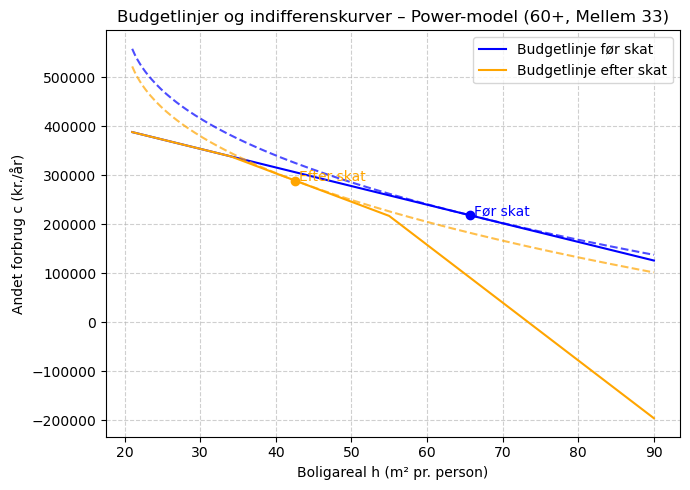

In [9]:
# Plot
import matplotlib.pyplot as plt
# -----------------------------
# FIGUR: Budgetlinje + indifferenskurver (Power-model)
# -----------------------------
sel = df[(df["Age"]=="60+") & (df["IncomeGroup"]=="Mellem 33")].iloc[0]
pars = age_params["60+"]
hbar, beta = pars["hbar"], pars["beta"]
p, y = sel["p_eff"], sel["Y"]

# Optimum før og efter skat
h_no_tax = hbar + (beta * SIGMA / p)**(1/(1 - SIGMA))
c_no_tax = y - p*h_no_tax
h_with_tax = hbar + (beta * SIGMA / (p + tau1))**(1/(1 - SIGMA))  # forenklet
c_with_tax = y - p*h_with_tax - T_total(h_with_tax)

# Budgetlinjer
h_vals = np.linspace(hbar+1, 90, 200)
c_no_tax_line = y - p*h_vals
c_with_tax_line = [y - p*h - T_total(h) for h in h_vals]

# Indifferenskurver (iso-nytte)
U_no_tax = c_no_tax + beta * (h_no_tax - hbar)**SIGMA
U_with_tax = c_with_tax + beta * (h_with_tax - hbar)**SIGMA
def indiff(U):
    return [U - beta * (h - hbar)**SIGMA for h in h_vals]

# Plot
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(h_vals, c_no_tax_line, label="Budgetlinje før skat", color="blue")
ax.plot(h_vals, c_with_tax_line, label="Budgetlinje efter skat", color="orange")
ax.plot(h_vals, indiff(U_no_tax), "--", color="blue", alpha=0.7)
ax.plot(h_vals, indiff(U_with_tax), "--", color="orange", alpha=0.7)
ax.scatter(h_no_tax, c_no_tax, color="blue")
ax.scatter(h_with_tax, c_with_tax, color="orange")
ax.text(h_no_tax+0.5, c_no_tax, "Før skat", color="blue")
ax.text(h_with_tax+0.5, c_with_tax, "Efter skat", color="orange")

ax.set_xlabel("Boligareal h (m² pr. person)")
ax.set_ylabel("Andet forbrug c (kr./år)")
ax.set_title("Budgetlinjer og indifferenskurver – Power-model (60+, Mellem 33)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [66]:
# -----------------------------
# POWER-MODEL – LEJEBOLIGMARKED
# -----------------------------
# β og h̄ (minimumsbehov) spiller sammen:
# - Selvom β er højere, kan marginalnytten være lavere,
#   hvis (h – h̄) er lille, eller hvis husholdningen allerede
#   ligger tæt på sit minimumsbehov.
# - 60+ har høj β og stort (h - h̄) → marginalnytten forbliver høj
#   → de bliver i store boliger og betaler skat.

import numpy as np
import pandas as pd

# -----------------------------
# DATA (lejeboliger, m² pr. person, månedlig husleje, indkomst)
# -----------------------------
rows = [
    ("18-29","Bund 33",   36.5, 7153.0, 104900),
    ("18-29","Mellem 33", 37.0, 7369.9, 185400),
    ("18-29","Top 33",    39.5, 8080.6, 314800),
    ("30-59","Bund 33",   37.0, 7575.4, 170900),
    ("30-59","Mellem 33", 40.0, 8694.2, 303700),
    ("30-59","Top 33",    47.0,11373.8, 464900),
    ("60+","Bund 33",     60.0, 6707.5, 175200),
    ("60+","Mellem 33",   66.0, 7909.5, 237200),
    ("60+","Top 33",      64.8, 9972.3, 404000),
]
df = pd.DataFrame(rows, columns=["Age","IncomeGroup","h_obs","RentMonth","Y"])

# Fælles årlig lejepris pr. m² (beregnet som gennemsnit over alle grupper)
p_eff_common = np.mean([r / h for r, h in zip(df["RentMonth"], df["h_obs"])]) * 12
df["p_eff"] = p_eff_common

print(f"Fælles årlig pris pr. m²: {p_eff_common:.0f} kr.\n")

# -----------------------------
# SKAT (progressiv pr. person)
# -----------------------------
h1, h2   = 34.0, 55.0
tau1, tau2 = 1000.0, 5000.0

def T_total(h):
    """Progressiv skat på boligkvadratmeter"""
    if h <= h1:
        return 0.0
    if h <= h2:
        return tau1*(h - h1)
    return tau1*(h2 - h1) + tau2*(h - h2)

# -----------------------------
# PARAMETRE: subsistens og power-nytte
# -----------------------------
H_BAR = {"18-29": 20, "30-59": 20, "60+": 20}
SIGMA = 0.4   # fælles elasticitet

# Kalibrér β så h_obs ≈ optimal h uden skat
def fit_beta_power(sub, hbar, sigma):
    p_mean = np.mean(sub["p_eff"])
    h_mean = np.mean(sub["h_obs"])
    beta = (p_mean / sigma) * (h_mean - hbar)**(1 - sigma)
    return max(beta, 1e-6)

age_params = {}
for age, sub in df.groupby("Age"):
    hbar = H_BAR[age]
    beta = fit_beta_power(sub, hbar, SIGMA)
    age_params[age] = {"hbar": hbar, "beta": beta}

# -----------------------------
# MODEL: power-quasilinear præferencer
# -----------------------------
def solve_power(y, p, hbar, beta, sigma):
    """Maksimerer U = c + beta*(h-hbar)^sigma under progressiv skat."""
    cand = []
    tol = 1e-6

    def add_candidate(tag, h):
        c = y - p*h - T_total(h)
        if (h > hbar + tol) and (c > tol):
            U = c + beta * (h - hbar)**sigma
            cand.append((tag, h, c, U, T_total(h)))

    # Kandidater fra FOC i hvert skatteinterval
    for (tau, lo, hi) in [(0.0, -np.inf, h1), (tau1, h1, h2), (tau2, h2, np.inf)]:
        h_k = hbar + (beta * sigma / (p + tau))**(1/(1 - sigma))
        if (h_k >= lo - 1e-3) and (h_k < hi + 1e-3):
            add_candidate(f"FOC τ={tau:.0f}", h_k)

    # Grænsepunkter (kinks)
    add_candidate(f"h={h1:.0f}", h1)
    add_candidate(f"h={h2:.0f}", h2)

    # No-tax FOC som check
    h_nt = hbar + (beta * sigma / p)**(1/(1 - sigma))
    add_candidate("FOC τ=0 (check)", h_nt)

    if not cand:
        h_eps = hbar + 1e-3
        add_candidate("min over hbar", h_eps)

    tag, h_star, c_star, U_star, T_star = max(cand, key=lambda t: t[3])
    return {"tag": tag, "h": h_star, "c": c_star, "U": U_star, "T": T_star}

# -----------------------------
# SIMULATION
# -----------------------------
rows_out = []
for _, r in df.iterrows():
    pars = age_params[r["Age"]]
    hbar, beta = pars["hbar"], pars["beta"]
    p = r["p_eff"]
    y = r["Y"]

    # uden skat
    h_nt = hbar + (beta * SIGMA / p)**(1/(1 - SIGMA))
    c_nt = y - p*h_nt
    U_nt = c_nt + beta * (h_nt - hbar)**SIGMA

    # med skat
    sol = solve_power(y, p, hbar, beta, SIGMA)
    h_tax, c_tax, U_tax, T_tax = sol["h"], sol["c"], sol["U"], sol["T"]

    rows_out.append({
        "Age": r["Age"],
        "IncomeGroup": r["IncomeGroup"],
        "hbar(age)": round(hbar,1),
        "beta(age)": round(beta,1),
        "h_obs": r["h_obs"],
        "h_pred_no_tax": h_nt,
        "h_pred_with_tax": h_tax,
        "Δh (m²)": h_tax - h_nt,
        "C_no_tax": c_nt,
        "C_with_tax": c_tax,
        "ΔC": c_tax - c_nt,
        "Tax_paid (DKK)": T_tax,
        "U_no_tax": U_nt,
        "U_with_tax": U_tax,
        "ΔU": U_tax - U_nt,
        "tag": sol["tag"]
    })

# Lav dataframe
res = pd.DataFrame(rows_out).sort_values(["Age","IncomeGroup"]).reset_index(drop=True)

# Samlet provenu og gennemsnitlig velfærdsændring
# Samlet provenu, gennemsnitlig velfærdsændring og frigivne m²
res["Weight"] = 1 / len(res)
total_revenue = res["Tax_paid (DKK)"].sum()
total_dU = (res["ΔU"] * res["Weight"]).sum()
freed = (res["h_pred_no_tax"] - res["h_pred_with_tax"]).sum()  # samlet frigivet m²

# -----------------------------
# OUTPUT
# -----------------------------
# -----------------------------
# OUTPUT
# -----------------------------
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print(f"Fælles sigma = {SIGMA}")
print("\nBASELINE PROGRESSIV SKAT (LEJER) (kr/m²)")
print(f"τ₁={tau1} kr/m², τ₂={tau2} kr/m², h₂={h2}")
print(f"Samlet provenu: {total_revenue:,.0f} kr   |   Gns. ΔU: {total_dU:,.2f}   |   Frigivne m²: {freed:,.2f}")
print("\nDetaljer:")

print("\nAldersparametre (power-nytte):")
for a, v in age_params.items():
    print(f"  {a}: hbar={v['hbar']:.1f}, beta={v['beta']:.1f}")

print("\nResultater (før/efter skat):")
print(res.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))



Fælles årlig pris pr. m²: 2199 kr.

Fælles sigma = 0.4

BASELINE PROGRESSIV SKAT (LEJER) (kr/m²)
τ₁=1000.0 kr/m², τ₂=5000.0 kr/m², h₂=55.0
Samlet provenu: 28,034 kr   |   Gns. ΔU: -6,808.50   |   Frigivne m²: 93.77

Detaljer:

Aldersparametre (power-nytte):
  18-29: hbar=20.0, beta=30795.3
  30-59: hbar=20.0, beta=34484.7
  60+: hbar=20.0, beta=52952.1

Resultater (før/efter skat):
  Age IncomeGroup  hbar(age)  beta(age)  h_obs  h_pred_no_tax  h_pred_with_tax  Δh (m²)   C_no_tax  C_with_tax        ΔC  Tax_paid (DKK)   U_no_tax  U_with_tax         ΔU        tag  Weight
18-29     Bund 33         20  30,795.30  36.50          37.67            34.00    -3.67  22,066.05   30,129.53  8,063.48            0.00 119,194.35  118,627.88    -566.47       h=34    0.11
18-29   Mellem 33         20  30,795.30  37.00          37.67            34.00    -3.67 102,566.05  110,629.53  8,063.48            0.00 199,694.35  199,127.88    -566.47       h=34    0.11
18-29      Top 33         20  30,795.30  39.5

In [80]:
# -----------------------------
# POWER-MODEL – LEJEBOLIGMARKED (9 individuelle β)
# -----------------------------
# Nu beregnes en separat beta for hver af de 9 undergrupper
# i stedet for én fælles pr. aldersgruppe.

import numpy as np
import pandas as pd

# -----------------------------
# DATA (lejeboliger, m² pr. person, månedlig husleje, indkomst)
# -----------------------------
rows = [
    ("18-29","Bund 33",   36.5, 7153.0, 104900),
    ("18-29","Mellem 33", 37.0, 7369.9, 185400),
    ("18-29","Top 33",    39.5, 8080.6, 314800),
    ("30-59","Bund 33",   37.0, 7575.4, 170900),
    ("30-59","Mellem 33", 40.0, 8694.2, 303700),
    ("30-59","Top 33",    47.0,11373.8, 464900),
    ("60+","Bund 33",     60.0, 6707.5, 175200),
    ("60+","Mellem 33",   66.0, 7909.5, 237200),
    ("60+","Top 33",      64.8, 9972.3, 404000),
]
df = pd.DataFrame(rows, columns=["Age","IncomeGroup","h_obs","RentMonth","Y"])

# -----------------------------
# Fælles årlig lejepris pr. m² (beregnet som gennemsnit over alle grupper)
# -----------------------------
p_eff_common = np.mean([r / h for r, h in zip(df["RentMonth"], df["h_obs"])]) * 12
df["p_eff"] = p_eff_common
print(f"Fælles årlig pris pr. m²: {p_eff_common:.0f} kr.\n")

# -----------------------------
# SKAT (progressiv pr. person)
# -----------------------------
h1, h2   = 34.0, 55.0
tau1, tau2 = 1000.0, 5000.0

def T_total(h):
    """Progressiv skat på boligkvadratmeter"""
    if h <= h1:
        return 0.0
    if h <= h2:
        return tau1*(h - h1)
    return tau1*(h2 - h1) + tau2*(h - h2)

# -----------------------------
# PARAMETRE
# -----------------------------
SIGMA = 0.4
H_BAR = {"18-29": 20, "30-59": 20, "60+": 20}

# Kalibrér individuel β for hver af de 9 undergrupper
def fit_beta_individual(h_obs, p, hbar, sigma):
    beta = (p / sigma) * (h_obs - hbar)**(1 - sigma)
    return max(beta, 1e-6)

df["beta"] = df.apply(lambda r: fit_beta_individual(r["h_obs"], r["p_eff"], H_BAR[r["Age"]], SIGMA), axis=1)

# -----------------------------
# MODEL: power-quasilinear præferencer
# -----------------------------
def solve_power(y, p, hbar, beta, sigma):
    """Maksimerer U = c + beta*(h-hbar)^sigma under progressiv skat."""
    cand = []
    tol = 1e-6

    def add_candidate(tag, h):
        c = y - p*h - T_total(h)
        if (h > hbar + tol) and (c > tol):
            U = c + beta * (h - hbar)**sigma
            cand.append((tag, h, c, U, T_total(h)))

    # Kandidater fra FOC i hvert skatteinterval
    for (tau, lo, hi) in [(0.0, -np.inf, h1), (tau1, h1, h2), (tau2, h2, np.inf)]:
        h_k = hbar + (beta * sigma / (p + tau))**(1/(1 - sigma))
        if (h_k >= lo - 1e-3) and (h_k < hi + 1e-3):
            add_candidate(f"FOC τ={tau:.0f}", h_k)

    # Grænsepunkter (kinks)
    add_candidate(f"h={h1:.0f}", h1)
    add_candidate(f"h={h2:.0f}", h2)

    # No-tax FOC som check
    h_nt = hbar + (beta * sigma / p)**(1/(1 - sigma))
    add_candidate("FOC τ=0 (check)", h_nt)

    if not cand:
        h_eps = hbar + 1e-3
        add_candidate("min over hbar", h_eps)

    tag, h_star, c_star, U_star, T_star = max(cand, key=lambda t: t[3])
    return {"tag": tag, "h": h_star, "c": c_star, "U": U_star, "T": T_star}

# -----------------------------
# SIMULATION
# -----------------------------
rows_out = []
for _, r in df.iterrows():
    hbar = H_BAR[r["Age"]]
    beta = r["beta"]
    p, y = r["p_eff"], r["Y"]

    # uden skat
    h_nt = hbar + (beta * SIGMA / p)**(1/(1 - SIGMA))
    c_nt = y - p*h_nt
    U_nt = c_nt + beta * (h_nt - hbar)**SIGMA

    # med skat
    sol = solve_power(y, p, hbar, beta, SIGMA)
    h_tax, c_tax, U_tax, T_tax = sol["h"], sol["c"], sol["U"], sol["T"]

    rows_out.append({
        "Age": r["Age"],
        "IncomeGroup": r["IncomeGroup"],
        "β": round(beta, 2),
        "h_obs": r["h_obs"],
        "h_pred_no_tax": h_nt,
        "h_pred_with_tax": h_tax,
        "Δh (m²)": h_tax - h_nt,
        "C_no_tax": c_nt,
        "C_with_tax": c_tax,
        "ΔC": c_tax - c_nt,
        "Tax_paid (DKK)": T_tax,
        "U_no_tax": U_nt,
        "U_with_tax": U_tax,
        "ΔU": U_tax - U_nt,
        "tag": sol["tag"]
    })

# -----------------------------
# RESULTATER
# -----------------------------
res = pd.DataFrame(rows_out).sort_values(["Age","IncomeGroup"]).reset_index(drop=True)
res["Weight"] = 1 / len(res)
total_revenue = res["Tax_paid (DKK)"].sum()
total_dU = (res["ΔU"] * res["Weight"]).sum()
freed = (res["h_pred_no_tax"] - res["h_pred_with_tax"]).sum()

# -----------------------------
# OUTPUT
# -----------------------------
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print(f"Fælles sigma = {SIGMA}")
print("\nPROGRESSIV SKAT (LEJER) (kr/m²)")
print(f"τ₁={tau1} kr/m², τ₂={tau2} kr/m², h₂={h2}")
print(f"Samlet provenu: {total_revenue:,.0f} kr   |   Gns. ΔU: {total_dU:,.2f}   |   Frigivne m²: {freed:,.2f}\n")

print("\nResultater (før/efter skat):")
print(res.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))

Fælles årlig pris pr. m²: 2199 kr.

Fælles sigma = 0.4

PROGRESSIV SKAT (LEJER) (kr/m²)
τ₁=1000.0 kr/m², τ₂=5000.0 kr/m², h₂=55.0
Samlet provenu: 28,490 kr   |   Gns. ΔU: -6,975.06   |   Frigivne m²: 93.31


Resultater (før/efter skat):
  Age IncomeGroup         β  h_obs  h_pred_no_tax  h_pred_with_tax  Δh (m²)   C_no_tax  C_with_tax        ΔC  Tax_paid (DKK)   U_no_tax  U_with_tax         ΔU        tag  Weight
18-29     Bund 33 29,558.44  36.50          36.50            34.00    -2.50  24,631.70   30,129.53  5,497.83            0.00 115,345.87  115,073.54    -272.33       h=34    0.11
18-29   Mellem 33 30,092.66  37.00          37.00            34.00    -3.00 104,032.13  110,629.53  6,597.39            0.00 197,495.22  197,108.75    -386.47       h=34    0.11
18-29      Top 33 32,674.73  39.50          39.50            34.00    -5.50 227,934.31  240,029.53 12,095.22            0.00 335,141.97  333,929.01  -1,212.96       h=34    0.11
30-59     Bund 33 30,092.66  37.00          37.00  

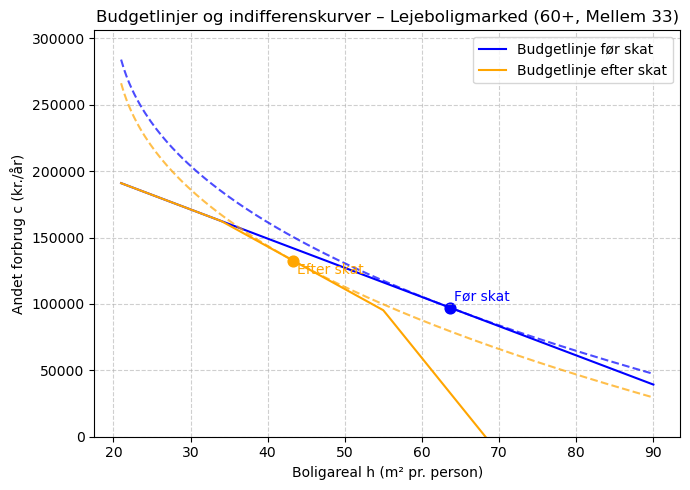

In [67]:
# FIGUR: Budgetlinjer og indifferenskurver – Lejeboligmarked (Power-model)
import matplotlib.pyplot as plt

# Vælg gruppe – fx 60+ Mellem 33 (du kan ændre her)
sel = df[(df["Age"] == "60+") & (df["IncomeGroup"] == "Mellem 33")].iloc[0]
pars = age_params["60+"]
hbar, beta = pars["hbar"], pars["beta"]
p, y = sel["p_eff"], sel["Y"]

# Optimum før og efter skat
h_no_tax = hbar + (beta * SIGMA / p)**(1 / (1 - SIGMA))
c_no_tax = y - p * h_no_tax
h_with_tax = hbar + (beta * SIGMA / (p + tau1))**(1 / (1 - SIGMA))  # forenklet
c_with_tax = y - p * h_with_tax - T_total(h_with_tax)

# Budgetlinjer
h_vals = np.linspace(hbar + 1, 90, 200)
c_no_tax_line = y - p * h_vals
c_with_tax_line = [y - p * h - T_total(h) for h in h_vals]

# Indifferenskurver (iso-nytte)
U_no_tax = c_no_tax + beta * (h_no_tax - hbar)**SIGMA
U_with_tax = c_with_tax + beta * (h_with_tax - hbar)**SIGMA

def indiff(U):
    return [U - beta * (h - hbar)**SIGMA for h in h_vals]

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(h_vals, c_no_tax_line, label="Budgetlinje før skat", color="blue")
ax.plot(h_vals, c_with_tax_line, label="Budgetlinje efter skat", color="orange")
ax.plot(h_vals, indiff(U_no_tax), "--", color="blue", alpha=0.7)
ax.plot(h_vals, indiff(U_with_tax), "--", color="orange", alpha=0.7)
ax.scatter(h_no_tax, c_no_tax, color="blue", s=60)
ax.scatter(h_with_tax, c_with_tax, color="orange", s=60)
ax.text(h_no_tax + 0.5, c_no_tax + 5000, "Før skat", color="blue")
ax.text(h_with_tax + 0.5, c_with_tax - 10000, "Efter skat", color="orange")

ax.set_xlabel("Boligareal h (m² pr. person)")
ax.set_ylabel("Andet forbrug c (kr./år)")
ax.set_title("Budgetlinjer og indifferenskurver – Lejeboligmarked (60+, Mellem 33)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_ylim(bottom=0)  # <- forhindrer negativt forbrug
plt.tight_layout()
plt.show()

In [70]:
# -----------------------------
# GRID-SØGNING - Provenu næsten det samme som baseline (1000 / 5000 / 55) men lidt højere velfærdstab + højere frigivne m²

import numpy as np
import pandas as pd

# --- DATA ---
rows = [
    ("18-29","Bund 33",   36.5, 7153.0, 104900),
    ("18-29","Mellem 33", 37.0, 7369.9, 185400),
    ("18-29","Top 33",    39.5, 8080.6, 314800),
    ("30-59","Bund 33",   37.0, 7575.4, 170900),
    ("30-59","Mellem 33", 40.0, 8694.2, 303700),
    ("30-59","Top 33",    47.0,11373.8, 464900),
    ("60+","Bund 33",     60.0, 6707.5, 175200),
    ("60+","Mellem 33",   66.0, 7909.5, 237200),
    ("60+","Top 33",      64.8, 9972.3, 404000),
]
df = pd.DataFrame(rows, columns=["Age","IncomeGroup","h_obs","RentMonth","Y"])

# Fælles årlig pris pr. m² (kr/m²/år)
p_eff_common = np.mean([r/h for r,h in zip(df["RentMonth"], df["h_obs"])]) * 12
df["p_eff"] = p_eff_common

# --- Skatteknæk & subsistens ---
h1 = 34.0
H_BAR = {"18-29": 20.0, "30-59": 20.0, "60+": 20.0}
SIGMA = 0.4

# --- Kalibrér beta pr. alder (matching h_obs i gennemsnit uden skat) ---
def fit_beta_power(sub, hbar, sigma):
    p_mean = np.mean(sub["p_eff"])
    h_mean = np.mean(sub["h_obs"])
    beta = (p_mean / sigma) * (h_mean - hbar)**(1 - sigma)
    return max(beta, 1e-8)

age_params = {}
for age, sub in df.groupby("Age"):
    hbar = H_BAR[age]
    beta = fit_beta_power(sub, hbar, SIGMA)
    age_params[age] = {"hbar": hbar, "beta": beta}

# --- Hjælper: løs for givet (tau1, tau2, h2) ---
def simulate_for_params(tau1, tau2, h2):
    def T_total(h):
        if h <= h1:       return 0.0
        if h <= h2:       return tau1*(h - h1)
        return tau1*(h2 - h1) + tau2*(h - h2)

    def solve_household(y, p, hbar, beta, sigma):
        cand = []
        tol = 1e-8

        def try_h(tag, h):
            if h <= hbar + tol:  # skal være strict over subsistens
                return
            c = y - p*h - T_total(h)
            if c <= tol:         # budget skal være positivt
                return
            U = c + beta*(h - hbar)**sigma
            cand.append((tag, h, c, U, T_total(h)))

        # FOC i hvert interval (marginalpris = p + τ)
        for (tau, lo, hi, tag) in [
            (0.0,   -np.inf, h1, "FOC τ=0 (under h1)"),
            (tau1,  h1,      h2, f"FOC τ={int(tau1)}"),
            (tau2,  h2,      np.inf, f"FOC τ={int(tau2)}"),
        ]:
            h_k = hbar + (beta*SIGMA / (p + tau))**(1/(1 - SIGMA))
            if lo - 1e-6 <= h_k < hi + 1e-6:
                try_h(tag, h_k)

        # Kinks + no-tax-Foc som kandidat
        try_h(f"h={h1}", h1)
        try_h(f"h={h2}", h2)
        h_nt = hbar + (beta*SIGMA / p)**(1/(1 - SIGMA))
        try_h("FOC τ=0 (no tax)", h_nt)

        if not cand:
            # fallback: lige over subsistens
            try_h("near hbar", hbar + 1e-3)

        # vælg max nytte
        tag, h_star, c_star, U_star, T_star = max(cand, key=lambda t: t[3])
        return {"tag": tag, "h": h_star, "c": c_star, "U": U_star, "T": T_star}

    rows = []
    for _, r in df.iterrows():
        pars = age_params[r["Age"]]
        hbar, beta, p, y = pars["hbar"], pars["beta"], r["p_eff"], r["Y"]

        # baseline (uden skat)
        h_nt = hbar + (beta*SIGMA / p)**(1/(1 - SIGMA))
        c_nt = y - p*h_nt
        U_nt = c_nt + beta*(h_nt - hbar)**SIGMA

        # med skat
        sol = solve_household(y, p, hbar, beta, SIGMA)

        rows.append({
            "Age": r["Age"], "IncomeGroup": r["IncomeGroup"],
            "h_no_tax": h_nt, "h_with_tax": sol["h"], "Δh": sol["h"] - h_nt,
            "Tax_paid": sol["T"], "U_no_tax": U_nt, "U_with_tax": sol["U"],
            "ΔU": sol["U"] - U_nt, "tag": sol["tag"]
        })

    res = pd.DataFrame(rows)
    return res, res["Tax_paid"].sum(), res["ΔU"].mean(), (res["h_no_tax"] - res["h_with_tax"]).sum()

# --- GRID (i **kr/m²**) – samme enheder som den “virkende” model ---
tau1_grid = [400, 500, 600]         # kr/m² mellem h1–h2 - når højere end 600 går middealdrene også ned til præcis 34 
tau2_grid = [3000, 4000, 6000]     # kr/m² over h2
h2_grid   = [55, 60]                 # knækpunkt 2

best = None
best_rev = -np.inf

# valgfri velfærdsgrænse (kan sættes til None for at slå fra)
WELFARE_FLOOR = -20000  # gennemsnitligt ΔU må ikke være lavere end dette

for t1 in tau1_grid:
    for t2 in tau2_grid:
        for h2 in h2_grid:
            res, rev, dU, freed = simulate_for_params(t1, t2, h2)
            if (WELFARE_FLOOR is None) or (dU >= WELFARE_FLOOR):
                if rev > best_rev:
                    best = (t1, t2, h2, rev, dU, freed, res)
                    best_rev = rev

# --- OUTPUT ---
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 180)

if best:
    t1, t2, h2, rev, dU, freed, res_best = best
    print("\nOPTIMERET SKAT (kr/m²) - Grid search")
    print(f"τ1={t1} kr/m², τ2={t2} kr/m², h2={h2}")
    print(f"Provenu: {rev:,.0f} kr   |   Gns. ΔU: {dU:,.2f}   |   Frigivne m²: {freed:,.2f}")
    print("\nDetaljer:")
    print(res_best.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))
else:
    print("Ingen kombination opfyldte betingelsen(e). Prøv at slække WELFARE_FLOOR eller grid-intervaller.")


OPTIMERET SKAT (kr/m²) - Grid search
τ1=600 kr/m², τ2=3000 kr/m², h2=55
Provenu: 27,784 kr   |   Gns. ΔU: -5,196.08   |   Frigivne m²: 75.49

Detaljer:
  Age IncomeGroup  h_no_tax  h_with_tax     Δh  Tax_paid   U_no_tax  U_with_tax         ΔU       tag
18-29     Bund 33     37.67       34.00  -3.67      0.00 119,194.35  118,627.88    -566.47    h=34.0
18-29   Mellem 33     37.67       34.00  -3.67      0.00 199,694.35  199,127.88    -566.47    h=34.0
18-29      Top 33     37.67       34.00  -3.67      0.00 329,094.35  328,527.88    -566.47    h=34.0
30-59     Bund 33     41.33       34.27  -7.06    162.29 197,289.58  195,234.79  -2,054.79 FOC τ=600
30-59   Mellem 33     41.33       34.27  -7.06    162.29 330,089.58  328,034.79  -2,054.79 FOC τ=600
30-59      Top 33     41.33       34.27  -7.06    162.29 491,289.58  489,234.79  -2,054.79 FOC τ=600
  60+     Bund 33     63.60       49.17 -14.43  9,099.17 275,040.57  262,073.60 -12,966.97 FOC τ=600
  60+   Mellem 33     63.60       49.17

In [50]:
# -----------------------------
# POWER-MODEL – LEJEBOLIGMARKED (KONTINUERLIG STIGENDE SKAT)
# SKATTEN SKAL HER STARTE FØR, altså måske fra 25/30 kvm på 0 kroner og så vokse, ellers kan vi ikke kontrollere for koncentrationer lige under skattegrænsen!!
# Skatten stiger lineært fra 500 kr/m² ved 34 m² til 5000 kr/m² ved 55 m².
# Efter 55 m² fastholdes marginalskatten på 5000 kr/m².
# Kontinueret stigende skat rammer de gamle endnu hårdere (går helt ned til 39 kvm)

import numpy as np
import pandas as pd

# -----------------------------
# DATA (lejeboliger, m² pr. person, månedlig husleje, indkomst)
# -----------------------------
rows = [
    ("18-29","Bund 33",   36.5, 7153.0, 104900),
    ("18-29","Mellem 33", 37.0, 7369.9, 185400),
    ("18-29","Top 33",    39.5, 8080.6, 314800),
    ("30-59","Bund 33",   37.0, 7575.4, 170900),
    ("30-59","Mellem 33", 40.0, 8694.2, 303700),
    ("30-59","Top 33",    47.0,11373.8, 464900),
    ("60+","Bund 33",     60.0, 6707.5, 175200),
    ("60+","Mellem 33",   66.0, 7909.5, 237200),
    ("60+","Top 33",      64.8, 9972.3, 404000),
]
df = pd.DataFrame(rows, columns=["Age","IncomeGroup","h_obs","RentMonth","Y"])

# -----------------------------
# Fælles årlig lejepris pr. m²
# -----------------------------
p_eff_common = np.mean([r / h for r, h in zip(df["RentMonth"], df["h_obs"])]) * 12
df["p_eff"] = p_eff_common
print(f"Fælles årlig pris pr. m²: {p_eff_common:.0f} kr.\n")

# -----------------------------
# KONTINUERLIG STIGENDE SKAT
# -----------------------------
h1, h2 = 34.0, 55.00
tau_min, tau_max = 500.0, 5000.0  # marginalskat fra 500 til 5000 kr/m²

def T_total(h):
    """Lineært stigende skat mellem h1 og h2."""
    if h <= h1:
        return 0.0
    elif h <= h2:
        # marginalskatten stiger lineært mellem h1 og h2
        slope = (tau_max - tau_min) / (h2 - h1)
        # integreret skat = trekant + rektangel
        return tau_min*(h - h1) + 0.5 * slope * (h - h1)**2
    else:
        # først hele stigningen, derefter flad marginal på tau_max
        slope = (tau_max - tau_min) / (h2 - h1)
        tax_up_to_h2 = tau_min*(h2 - h1) + 0.5 * slope * (h2 - h1)**2
        return tax_up_to_h2 + tau_max*(h - h2)

# -----------------------------
# PARAMETRE: subsistens og power-nytte
# -----------------------------
H_BAR = {"18-29": 20, "30-59": 20, "60+": 20}
SIGMA = 0.4

# Kalibrér β
def fit_beta_power(sub, hbar, sigma):
    p_mean = np.mean(sub["p_eff"])
    h_mean = np.mean(sub["h_obs"])
    beta = (p_mean / sigma) * (h_mean - hbar)**(1 - sigma)
    return max(beta, 1e-6)

age_params = {}
for age, sub in df.groupby("Age"):
    hbar = H_BAR[age]
    beta = fit_beta_power(sub, hbar, SIGMA)
    age_params[age] = {"hbar": hbar, "beta": beta}

# -----------------------------
# MODEL: power-quasilinear præferencer
# -----------------------------
def solve_power(y, p, hbar, beta, sigma):
    """Maksimerer U = c + β*(h-hbar)^σ under stigende skat."""
    h_grid = np.linspace(hbar + 0.01, 100, 1000)
    best = None
    for h in h_grid:
        c = y - p*h - T_total(h)
        if c <= 0:
            continue
        U = c + beta*(h - hbar)**sigma
        if (best is None) or (U > best[2]):
            best = (h, c, U)
    if best is None:
        return {"h": hbar, "c": 0, "U": 0, "T": 0}
    h_star, c_star, U_star = best
    return {"h": h_star, "c": c_star, "U": U_star, "T": T_total(h_star)}

# -----------------------------
# SIMULATION
# -----------------------------
rows_out = []
for _, r in df.iterrows():
    pars = age_params[r["Age"]]
    hbar, beta = pars["hbar"], pars["beta"]
    p, y = r["p_eff"], r["Y"]

    # Uden skat
    h_nt = hbar + (beta * SIGMA / p)**(1/(1 - SIGMA))
    c_nt = y - p*h_nt
    U_nt = c_nt + beta*(h_nt - hbar)**SIGMA

    # Med stigende skat
    sol = solve_power(y, p, hbar, beta, SIGMA)
    h_tax, c_tax, U_tax, T_tax = sol["h"], sol["c"], sol["U"], sol["T"]

    rows_out.append({
        "Age": r["Age"],
        "IncomeGroup": r["IncomeGroup"],
        "h_pred_no_tax": h_nt,
        "h_pred_with_tax": h_tax,
        "Δh (m²)": h_tax - h_nt,
        "Tax_paid (DKK)": T_tax,
        "U_no_tax": U_nt,
        "U_with_tax": U_tax,
        "ΔU": U_tax - U_nt
    })

# -----------------------------
# RESULTATER
# -----------------------------
res = pd.DataFrame(rows_out)
total_revenue = res["Tax_paid (DKK)"].sum()
avg_dU = res["ΔU"].mean()
freed_m2 = (res["h_pred_no_tax"] - res["h_pred_with_tax"]).sum()

# -----------------------------
# OUTPUT
# -----------------------------
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 200)

print("\n----------------------------------")
print("LINEÆRT STIGENDE SKAT (500 → 5000 kr/m²)")
print("----------------------------------")
print(f"Samlet provenu: {total_revenue:,.0f} DKK")
print(f"Gennemsnitligt velfærdstab: {avg_dU:,.2f}")
print(f"Frigivne m² (sum af h_no_tax - h_with_tax): {freed_m2:,.2f}\n")
print(res.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

Fælles årlig pris pr. m²: 2199 kr.


----------------------------------
LINEÆRT STIGENDE SKAT (500 → 5000 kr/m²)
----------------------------------
Samlet provenu: 14,011 DKK
Gennemsnitligt velfærdstab: -7,137.15
Frigivne m² (sum af h_no_tax - h_with_tax): 106.95

  Age IncomeGroup  h_pred_no_tax  h_pred_with_tax  Δh (m²)  Tax_paid (DKK)   U_no_tax  U_with_tax         ΔU
18-29     Bund 33          37.67            34.02    -3.64           11.18 119,194.35  118,624.00    -570.35
18-29   Mellem 33          37.67            34.02    -3.64           11.18 199,694.35  199,124.00    -570.35
18-29      Top 33          37.67            34.02    -3.64           11.18 329,094.35  328,524.00    -570.35
30-59     Bund 33          41.33            34.42    -6.91          230.44 197,289.58  195,256.56  -2,033.02
30-59   Mellem 33          41.33            34.42    -6.91          230.44 330,089.58  328,056.56  -2,033.02
30-59      Top 33          41.33            34.42    -6.91          230.44 491,28

In [78]:
#LEJEBOLIGMARKED- KOTINUERLIG stigende fra 30 kvm (0 kr) - 60 kvm (5000 kr)  (3 BETA)
# Modellen giver sammenlignet med baseline et lidt lavere provenu men større frigivne m^2, samt lidt højere samlet velfærdstab
import numpy as np
import pandas as pd

# -----------------------------
# DATA (lejeboliger, m² pr. person, månedlig husleje, indkomst)
# -----------------------------
rows = [
    ("18-29","Bund 33",   36.5, 7153.0, 104900),
    ("18-29","Mellem 33", 37.0, 7369.9, 185400),
    ("18-29","Top 33",    39.5, 8080.6, 314800),
    ("30-59","Bund 33",   37.0, 7575.4, 170900),
    ("30-59","Mellem 33", 40.0, 8694.2, 303700),
    ("30-59","Top 33",    47.0,11373.8, 464900),
    ("60+","Bund 33",     60.0, 6707.5, 175200),
    ("60+","Mellem 33",   66.0, 7909.5, 237200),
    ("60+","Top 33",      64.8, 9972.3, 404000),
]
df = pd.DataFrame(rows, columns=["Age","IncomeGroup","h_obs","RentMonth","Y"])

# -----------------------------
# Fælles årlig lejepris pr. m²
# -----------------------------
p_eff_common = np.mean([r / h for r, h in zip(df["RentMonth"], df["h_obs"])]) * 12
df["p_eff"] = p_eff_common
print(f"Fælles årlig pris pr. m²: {p_eff_common:.0f} kr.\n")

# -----------------------------
# KONTINUERLIG STIGENDE SKAT
# -----------------------------
h1, h2 = 25.0, 60.00
tau_min, tau_max = 0.0, 5000.0  # marginalskat fra 500 til 5000 kr/m²

def T_total(h):
    """Lineært stigende skat mellem h1 og h2."""
    if h <= h1:
        return 0.0
    elif h <= h2:
        # marginalskatten stiger lineært mellem h1 og h2
        slope = (tau_max - tau_min) / (h2 - h1)
        # integreret skat = trekant + rektangel
        return tau_min*(h - h1) + 0.5 * slope * (h - h1)**2
    else:
        # først hele stigningen, derefter flad marginal på tau_max
        slope = (tau_max - tau_min) / (h2 - h1)
        tax_up_to_h2 = tau_min*(h2 - h1) + 0.5 * slope * (h2 - h1)**2
        return tax_up_to_h2 + tau_max*(h - h2)

# -----------------------------
# PARAMETRE: subsistens og power-nytte
# -----------------------------
H_BAR = {"18-29": 20, "30-59": 20, "60+": 20}
SIGMA = 0.4

# Kalibrér β
def fit_beta_power(sub, hbar, sigma):
    p_mean = np.mean(sub["p_eff"])
    h_mean = np.mean(sub["h_obs"])
    beta = (p_mean / sigma) * (h_mean - hbar)**(1 - sigma)
    return max(beta, 1e-6)

age_params = {}
for age, sub in df.groupby("Age"):
    hbar = H_BAR[age]
    beta = fit_beta_power(sub, hbar, SIGMA)
    age_params[age] = {"hbar": hbar, "beta": beta}

# -----------------------------
# MODEL: power-quasilinear præferencer
# -----------------------------
def solve_power(y, p, hbar, beta, sigma):
    """Maksimerer U = c + β*(h-hbar)^σ under stigende skat."""
    h_grid = np.linspace(hbar + 0.01, 100, 1000)
    best = None
    for h in h_grid:
        c = y - p*h - T_total(h)
        if c <= 0:
            continue
        U = c + beta*(h - hbar)**sigma
        if (best is None) or (U > best[2]):
            best = (h, c, U)
    if best is None:
        return {"h": hbar, "c": 0, "U": 0, "T": 0}
    h_star, c_star, U_star = best
    return {"h": h_star, "c": c_star, "U": U_star, "T": T_total(h_star)}

# -----------------------------
# SIMULATION
# -----------------------------
rows_out = []
for _, r in df.iterrows():
    pars = age_params[r["Age"]]
    hbar, beta = pars["hbar"], pars["beta"]
    p, y = r["p_eff"], r["Y"]

    # Uden skat
    h_nt = hbar + (beta * SIGMA / p)**(1/(1 - SIGMA))
    c_nt = y - p*h_nt
    U_nt = c_nt + beta*(h_nt - hbar)**SIGMA

    # Med stigende skat
    sol = solve_power(y, p, hbar, beta, SIGMA)
    h_tax, c_tax, U_tax, T_tax = sol["h"], sol["c"], sol["U"], sol["T"]

    rows_out.append({
        "Age": r["Age"],
        "IncomeGroup": r["IncomeGroup"],
        "h_pred_no_tax": h_nt,
        "h_pred_with_tax": h_tax,
        "Δh (m²)": h_tax - h_nt,
        "Tax_paid (DKK)": T_tax,
        "U_no_tax": U_nt,
        "U_with_tax": U_tax,
        "ΔU": U_tax - U_nt
    })

# -----------------------------
# RESULTATER
# -----------------------------
res = pd.DataFrame(rows_out)
total_revenue = res["Tax_paid (DKK)"].sum()
avg_dU = res["ΔU"].mean()
freed_m2 = (res["h_pred_no_tax"] - res["h_pred_with_tax"]).sum()

# -----------------------------
# OUTPUT
# -----------------------------
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 200)

print("\n----------------------------------")
print("LINEÆRT STIGENDE SKAT (0 → 5000 kr/m²)")
print("----------------------------------")
print(f"Samlet provenu: {total_revenue:,.0f} DKK")
print(f"Gennemsnitligt velfærdstab: {avg_dU:,.2f}")
print(f"Frigivne m² (sum af h_no_tax - h_with_tax): {freed_m2:,.2f}\n")
print(res.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

Fælles årlig pris pr. m²: 2199 kr.


----------------------------------
LINEÆRT STIGENDE SKAT (0 → 5000 kr/m²)
----------------------------------
Samlet provenu: 46,252 DKK
Gennemsnitligt velfærdstab: -12,917.19
Frigivne m² (sum af h_no_tax - h_with_tax): 130.49

  Age IncomeGroup  h_pred_no_tax  h_pred_with_tax  Δh (m²)  Tax_paid (DKK)   U_no_tax  U_with_tax         ΔU
18-29     Bund 33          37.67            30.58    -7.09        2,223.43 119,194.35  114,545.07  -4,649.28
18-29   Mellem 33          37.67            30.58    -7.09        2,223.43 199,694.35  195,045.07  -4,649.28
18-29      Top 33          37.67            30.58    -7.09        2,223.43 329,094.35  324,445.07  -4,649.28
30-59     Bund 33          41.33            31.70    -9.63        3,206.65 197,289.58  190,217.17  -7,072.41
30-59   Mellem 33          41.33            31.70    -9.63        3,206.65 330,089.58  323,017.17  -7,072.41
30-59      Top 33          41.33            31.70    -9.63        3,206.65 491,289

In [79]:
# LEJEBOLIGMARKED – KONTINUERLIG STIGENDE SKAT (9 Beta)
# 9 individuelle beta-parametre (en pr. alders-/indkomstgruppe)

import numpy as np
import pandas as pd

# -----------------------------
# DATA
# -----------------------------
rows = [
    ("18-29","Bund 33",   36.5, 7153.0, 104900),
    ("18-29","Mellem 33", 37.0, 7369.9, 185400),
    ("18-29","Top 33",    39.5, 8080.6, 314800),
    ("30-59","Bund 33",   37.0, 7575.4, 170900),
    ("30-59","Mellem 33", 40.0, 8694.2, 303700),
    ("30-59","Top 33",    47.0,11373.8, 464900),
    ("60+","Bund 33",     60.0, 6707.5, 175200),
    ("60+","Mellem 33",   66.0, 7909.5, 237200),
    ("60+","Top 33",      64.8, 9972.3, 404000),
]
df = pd.DataFrame(rows, columns=["Age","IncomeGroup","h_obs","RentMonth","Y"])

# -----------------------------
# Fælles pris pr. m²
# -----------------------------
p_eff_common = np.mean([r / h for r, h in zip(df["RentMonth"], df["h_obs"])]) * 12
df["p_eff"] = p_eff_common
print(f"Fælles årlig pris pr. m²: {p_eff_common:.0f} kr.\n")

# -----------------------------
# KONTINUERLIG STIGENDE SKAT
# -----------------------------
h1, h2 = 30.0, 60.0
tau_min, tau_max = 0.0, 5000.0  # marginalskat fra 0 til 5000 kr/m²

def T_total(h):
    """Lineært stigende skat mellem h1 og h2."""
    if h <= h1:
        return 0.0
    elif h <= h2:
        slope = (tau_max - tau_min) / (h2 - h1)
        return tau_min*(h - h1) + 0.5 * slope * (h - h1)**2
    else:
        slope = (tau_max - tau_min) / (h2 - h1)
        tax_up_to_h2 = tau_min*(h2 - h1) + 0.5 * slope * (h2 - h1)**2
        return tax_up_to_h2 + tau_max*(h - h2)

# -----------------------------
# PARAMETRE
# -----------------------------
SIGMA = 0.4
H_BAR = {"18-29": 20, "30-59": 20, "60+": 20}

# Kalibrér individuel β for hver af de 9 grupper
def fit_beta_individual(h_obs, p, hbar, sigma):
    beta = (p / sigma) * (h_obs - hbar)**(1 - sigma)
    return max(beta, 1e-6)

df["beta"] = df.apply(lambda r: fit_beta_individual(r["h_obs"], r["p_eff"], H_BAR[r["Age"]], SIGMA), axis=1)

# -----------------------------
# LØSNING AF MODELLEN
# -----------------------------
def solve_power(y, p, hbar, beta, sigma):
    """Maksimerer U = c + β*(h-hbar)^σ under stigende skat."""
    h_grid = np.linspace(hbar + 0.01, 100, 1500)
    best = None
    for h in h_grid:
        c = y - p*h - T_total(h)
        if c <= 0:
            continue
        U = c + beta*(h - hbar)**sigma
        if (best is None) or (U > best[2]):
            best = (h, c, U)
    if best is None:
        return {"h": hbar, "c": 0, "U": 0, "T": 0}
    h_star, c_star, U_star = best
    return {"h": h_star, "c": c_star, "U": U_star, "T": T_total(h_star)}

# -----------------------------
# SIMULATION
# -----------------------------
rows_out = []
for _, r in df.iterrows():
    hbar = H_BAR[r["Age"]]
    beta = r["beta"]
    p, y = r["p_eff"], r["Y"]

    # Uden skat
    h_nt = hbar + (beta * SIGMA / p)**(1/(1 - SIGMA))
    c_nt = y - p*h_nt
    U_nt = c_nt + beta*(h_nt - hbar)**SIGMA

    # Med skat
    sol = solve_power(y, p, hbar, beta, SIGMA)
    h_tax, c_tax, U_tax, T_tax = sol["h"], sol["c"], sol["U"], sol["T"]

    rows_out.append({
        "Age": r["Age"],
        "IncomeGroup": r["IncomeGroup"],
        "β": round(beta, 2),
        "h_pred_no_tax": h_nt,
        "h_pred_with_tax": h_tax,
        "Δh (m²)": h_tax - h_nt,
        "Tax_paid (DKK)": T_tax,
        "U_no_tax": U_nt,
        "U_with_tax": U_tax,
        "ΔU": U_tax - U_nt
    })

# -----------------------------
# RESULTATER
# -----------------------------
res = pd.DataFrame(rows_out)
total_revenue = res["Tax_paid (DKK)"].sum()
avg_dU = res["ΔU"].mean()
freed_m2 = (res["h_pred_no_tax"] - res["h_pred_with_tax"]).sum()

# -----------------------------
# OUTPUT
# -----------------------------
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 200)

print("\n----------------------------------")
print("LINEÆRT STIGENDE SKAT (0 → 5000 kr/m²)")
print("----------------------------------")
print(f"Samlet provenu: {total_revenue:,.0f} DKK")
print(f"Gennemsnitligt velfærdstab: {avg_dU:,.2f}")
print(f"Frigivne m² (sum af h_no_tax - h_with_tax): {freed_m2:,.2f}\n")
print(res.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

Fælles årlig pris pr. m²: 2199 kr.


----------------------------------
LINEÆRT STIGENDE SKAT (0 → 5000 kr/m²)
----------------------------------
Samlet provenu: 24,950 DKK
Gennemsnitligt velfærdstab: -8,607.29
Frigivne m² (sum af h_no_tax - h_with_tax): 111.85

  Age IncomeGroup         β  h_pred_no_tax  h_pred_with_tax  Δh (m²)  Tax_paid (DKK)   U_no_tax  U_with_tax         ΔU
18-29     Bund 33 29,558.44          36.50            32.44    -4.06          497.52 115,345.87  114,087.30  -1,258.57
18-29   Mellem 33 30,092.66          37.00            32.60    -4.40          564.85 197,495.22  196,055.33  -1,439.89
18-29      Top 33 32,674.73          39.50            33.35    -6.15          935.52 335,141.97  332,654.48  -2,487.49
30-59     Bund 33 30,092.66          37.00            32.60    -4.40          564.85 182,995.22  181,555.33  -1,439.89
30-59   Mellem 33 33,174.87          40.00            33.51    -6.49        1,027.05 325,691.31  322,968.20  -2,723.12
30-59      Top 33 39,72